Mofied code based on the tutorial shared by
https://github.com/MagriLab/Tutorials/blob/main/ESN_Tutorial_Lorenz63.ipynb

Training data shape: (10000, 3)
U_val shape:         (5000, 3)
U_test shape:        (95801, 3)
Input to run_gp:([Real(low=0.5, high=1.25, prior='uniform', transform='identity'), Real(low=-1.0, high=1.0, prior='uniform', transform='identity'), Integer(low=-9.0, high=-3.0, prior='uniform', transform='identity')], 30, 10, 20)
--NEW RUN-- 1
Realisation: 0
spectral_radius 0.9446334636687639
input_scaling 4.881255012149711
tikhonov 0.0001


Val regime: 0
Fold: 0 , fold error:  0.20565744622079069
Fold: 1 , fold error:  0.11391746111827718
Val regime error: 0.15978745366953392
Realisation error: 0.15978745366953392


Realisation: 1
spectral_radius 0.9446334636687639
input_scaling 4.881255012149711
tikhonov 0.0001


Val regime: 0
Fold: 0 , fold error:  7.147006891206861
Fold: 1 , fold error:  0.34814232661497646
Val regime error: 3.7475746089109188
Realisation error: 3.7475746089109188


Realisation: 2
spectral_radius 0.9446334636687639
input_scaling 4.881255012149711
tikhonov 0.0001


Val reg

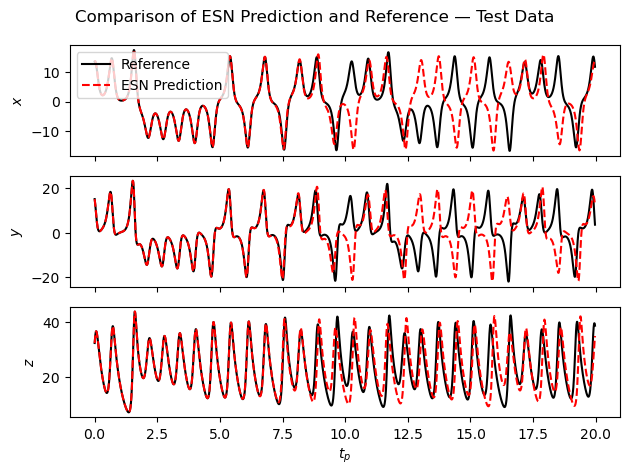

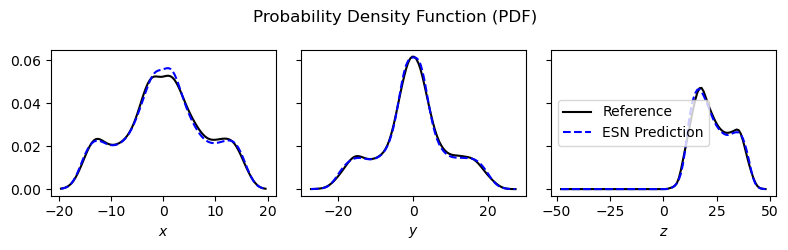

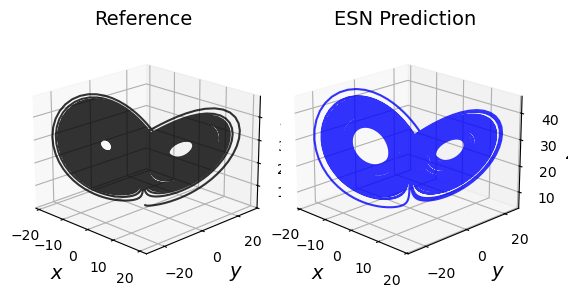

Average prediction horizon: 8.66 Lyapunov times


In [ ]:

import numpy as np
import scipy
import scipy.stats as stats
import itertools
import math
import matplotlib.pyplot as plt
from typing import Optional

# =============================================================================
# equations.py — Dynamical systems and RK4 integrators
# =============================================================================

def roessler(u, params):
    a, b, c = params
    x, y, z = u
    return np.array([-y - z, x + a*y, b + z*(x-c)])


def rosjac(u, params):
    a, b, c = params
    x, y, z = u
    J = np.array([[0, -1,  -1],
                  [1,  a,   0],
                  [z,  0, x-c]])
    return J


def lorenz63(u, params):
    beta, rho, sigma = params
    x, y, z = u
    return np.array([sigma*(y-x), x*(rho-z)-y, x*y-beta*z])


def lorenz63jac(u, params):
    beta, rho, sigma = params
    x, y, z = u
    J = np.array([[-sigma, sigma,     0],
                  [rho-z,    -1,    -x],
                  [y,     x, -beta]])
    return J


def lorenz96(x, p):
    return np.roll(x, 1) * (np.roll(x, -1) - np.roll(x, 2)) - x + p


def lorenz96jac(x, p):
    D = len(x)
    J = np.zeros((D, D), dtype='float')
    for i in range(D):
        J[i, (i-1) % D] =  x[(i+1) % D] - x[(i-2) % D]
        J[i, (i+1) % D] =  x[(i-1) % D]
        J[i, (i-2) % D] = -x[(i-1) % D]
        J[i, i] = -1.0
    return J


def RK4(ddt, u0, T, params):
    u = np.empty((T.size, u0.size))
    u[0] = u0
    der = np.empty((T.size, u0.size))
    for i in range(1, T.size):
        delta_t = (T[i] - T[i-1])
        K1 = ddt(u[i-1], params)
        K2 = ddt(u[i-1] + delta_t*K1/2.0, params)
        K3 = ddt(u[i-1] + delta_t*K2/2.0, params)
        K4 = ddt(u[i-1] + delta_t*K3, params)
        u[i:] = u[i-1] + np.array(delta_t * (K1/2.0 + K2 + K3 + K4/2.0) / 3.0)
        der[i-1] = K1
    return u, der


def solve_rk4(function, N, dt, u0, params):
    T = np.arange(N+1) * dt
    U, rhs = RK4(function, u0, T, params)
    return T, U, rhs


# =============================================================================
# errors.py — Error metrics
# =============================================================================

def L2(y, y_pred, axis=None):
    return np.linalg.norm(y - y_pred, axis=axis)


def rel_L2(y, y_pred, axis=None):
    return L2(y, y_pred, axis=axis) / np.linalg.norm(y, axis=axis)


def mse(y, y_pred, axis=None):
    return np.mean((y - y_pred) ** 2, axis=axis)


def rmse(y, y_pred, axis=None):
    return np.sqrt(mse(y, y_pred, axis))


def nrmse_errors(y, y_pred, axis=None, normalize_by="rms"):
    if normalize_by == "rms":
        norm = np.sqrt(np.mean(y, axis=0) ** 2)
    elif normalize_by == "maxmin":
        norm = np.max(y, axis=0) - np.min(y, axis=0)
    elif normalize_by == "std":
        norm = np.std(y, axis=0) ** 2
    return np.mean(rmse(y, y_pred, axis=0) / norm, axis=axis)


# =============================================================================
# scalers.py / reverse_scalers.py — Parameter scaling utilities
# =============================================================================

class scalers:
    @staticmethod
    def uniform(x):
        return x

    @staticmethod
    def log10(x):
        return np.log10(x)


class reverse_scalers:
    @staticmethod
    def uniform(x):
        return x

    @staticmethod
    def log10(x):
        return 10.0 ** x


# =============================================================================
# metrics.py — NRMSE and Valid Prediction Time
# =============================================================================

def nrmse(pred: np.ndarray, df_test: np.ndarray, n_length: Optional[int] = None) -> float:
    """Normalized RMSE between prediction and ground truth."""
    if n_length is None:
        n_length = min(len(pred), df_test.shape[1])
    std = np.std(df_test[:, :n_length])
    diff = pred[:n_length, :] - df_test[:, :n_length].T
    return np.sqrt(np.mean(diff**2 / std))


def vpt(pred: np.ndarray, df_test: np.ndarray, threshold: float) -> int:
    """Valid Prediction Time: last time step before NRMSE exceeds threshold."""
    for i in range(1, len(pred)):
        nrmse_i = nrmse(pred, df_test, n_length=i)
        if nrmse_i > threshold:
            return i - 1
    return len(pred)


def nrmse_array(pred: np.ndarray, df_test: np.ndarray) -> np.ndarray:
    """Returns NRMSE over time as an array."""
    return np.array([nrmse(pred, df_test, n_length=i) for i in range(1, len(pred))])


# =============================================================================
# tools.py — Lyapunov exponent computation utilities
# =============================================================================

def F_all(u, M, system, jacobian, params):
    dqdt = system(u, params)
    J = jacobian(u, params)
    dMdt = np.dot(J, M)
    return dqdt, dMdt


def RK4var(x, dt, mat, system, jacobian, params):
    K1, M1 = F_all(x, mat, system, jacobian, params)
    K2, M2 = F_all(x + dt*K1/2.0, mat + dt*M1/2.0, system, jacobian, params)
    K3, M3 = F_all(x + dt*K2/2.0, mat + dt*M2/2.0, system, jacobian, params)
    K4, M4 = F_all(x + dt*K3,     mat + dt*M3,      system, jacobian, params)
    A = np.array(dt * (K1/2.0 + K2 + K3 + K4/2.0) / 3.0)
    B = np.array(dt * (M1/2.0 + M2 + M3 + M4/2.0) / 3.0)
    return A, B


def qr_factorization(A):
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            q = Q[:, i]
            R[i, j] = q.dot(v)
            v = v - R[i, j] * q
        norm = np.linalg.norm(v)
        Q[:, j] = v / norm
        R[j, j] = norm
    return Q, R


def normalize(M):
    nM = np.zeros(M.shape)
    nV = np.zeros(np.shape(M)[1])
    for i in range(M.shape[1]):
        nV[i] = scipy.linalg.norm(M[:, i])
        nM[:, i] = M[:, i] / nV[i]
    return nM, nV


def timeseriesdot(x, y, multype):
    return np.einsum(multype, x, y.T)


def CLV_angles(clv, NLy):
    thetas_num = int(math.factorial(NLy) / (math.factorial(2) * math.factorial(NLy-2)))
    costhetas = np.zeros((clv[:, 0, :].shape[1], thetas_num))
    count = 0
    for subset in itertools.combinations(np.arange(NLy), 2):
        index1, index2 = subset
        costhetas[:, count] = np.absolute(
            timeseriesdot(clv[:, index1, :], clv[:, index2, :], 'ij,ji->j'))
        count += 1
    return 180. * np.arccos(costhetas) / math.pi


def CLV_calculation(QQ, RR, NLy, delta_dim, sampling=10):
    print('start CLV calculation')
    QQ = QQ[:, :, ::sampling]
    RR = RR[:, :, ::sampling]
    NLy = int(NLy/sampling) - 1
    tly = np.shape(QQ)[-1]

    C = np.zeros((NLy, NLy, tly))
    D = np.zeros((NLy, NLy, tly))
    V = np.zeros((delta_dim, NLy, tly))

    C[:, :, -1] = np.eye(NLy)
    D[:, :, -1] = np.eye(NLy)
    V[:, :, -1] = np.dot(np.real(QQ[:, :, -1]), C[:, :, -1])

    for i in reversed(range(tly-1)):
        C[:, :, i], D[:, :, i] = normalize(
            scipy.linalg.solve_triangular(np.real(RR[:, :, i]), C[:, :, i+1]))
        V[:, :, i] = np.dot(np.real(QQ[:, :, i]), C[:, :, i])

    timetot = np.shape(V)[-1]
    for i in range(NLy):
        for t in range(timetot):
            V[:, i, t] = V[:, i, t] / np.linalg.norm(V[:, i, t])

    return CLV_angles(V, NLy)


def solve_ode_LEs(N, N_trans, dt, u0, system, jacobian, params,
                  norm_time=1, dim=3, clv_angles=False):
    """Solve ODE and compute Lyapunov spectrum via QR decomposition."""
    N_test = N - N_trans
    print('Number of timesteps:', N)
    print('Number of timesteps for Lyapunov exponents:', N_test)

    T = np.arange(N+1) * dt
    Ttest = np.arange(1, int(N_test)+1) * dt
    u = u0.copy()
    U = np.empty((T.size, u0.size))
    U[0] = u0

    N_test_norm = int(N_test / norm_time)
    LE   = np.zeros((N_test_norm, dim))
    IBLE = np.zeros((N_test_norm, dim))
    qq_t = np.zeros((dim, dim, N_test_norm))
    rr_t = np.zeros((dim, dim, N_test_norm))

    np.random.seed(0)
    delta = scipy.linalg.orth(np.random.rand(dim, dim))
    Q, R = qr_factorization(delta)
    delta = Q[:, :dim]

    for i in range(1, T.size):
        u_t, Mtemp = RK4var(u, dt, delta, system, jacobian, params)
        u += u_t
        delta += Mtemp
        Q, R = qr_factorization(delta)
        delta = Q[:, :dim]

        if i > N_trans:
            idx = i - N_trans - 1
            LE[idx] = np.abs(np.diag(R))
            Jacobian = jacobian(u, params)
            rr_t[:, :, idx] = R
            qq_t[:, :, idx] = Q
            for j in range(dim):
                IBLE[idx, j] = np.dot(Q[:, j].T, np.dot(Jacobian, Q[:, j]))
        U[i] = u

    LEs = np.cumsum(np.log(LE), axis=0) / np.tile(Ttest, (dim, 1)).T
    print(f'Lyapunov Exponents: {LEs[-1]}')

    if clv_angles:
        thetas_clv = CLV_calculation(qq_t, rr_t, N_test_norm, dim)
        return T, U, LEs, IBLE, thetas_clv
    return T, U, LEs, IBLE


# =============================================================================
# esn_lorenz_optimized.ipynb — ESN Training and Prediction
# =============================================================================

# NOTE: The ESN-specific imports below come from external packages (esn.*).
# Make sure they are installed/accessible in your environment.
from esn.utils import errors  # noqa: E402  (uses rmse from errors module above)
from esn.validation import validate, set_ESN
from esn.esn import ESN


def main():
    # -------------------------------------------------------------------------
    # 1. Generate Lorenz 63 data
    # -------------------------------------------------------------------------
    dim = 3
    params = [2.667, 28, 10]        # beta, rho, sigma
    u0 = np.array([0.0, 1.0, 1.0])
    dt = 0.01
    t_lyap = 0.9 ** (-1)            # Lyapunov time
    N_lyap = int(t_lyap / dt)
    N_trans = 0
    N_total = 1000 * N_lyap + N_trans

    time_array, U_rk4, derU = solve_rk4(lorenz63, N_total, dt, u0=u0, params=params)
    upsampling = 1
    time_array = time_array[N_trans::upsampling]
    U_rk4 = U_rk4[N_trans::upsampling, :dim]

    # -------------------------------------------------------------------------
    # 2. Split into washout / train / validation / test sets
    # -------------------------------------------------------------------------
    washout_size     = 100
    train_size       = 10000
    val_size         = 5000
    test_washout_size = 100

    U_washout     = U_rk4[:washout_size, :]
    U_train_input = U_rk4[washout_size:washout_size + train_size, :]
    U_train_label = U_rk4[washout_size + 1: washout_size + train_size + 1, :]
    U_val_input   = U_rk4[washout_size + train_size: washout_size + train_size + val_size, :]
    U_val_label   = U_rk4[washout_size + train_size + 1: washout_size + train_size + val_size + 1, :]
    U_test_washout = U_rk4[washout_size + train_size + val_size:
                            washout_size + train_size + val_size + test_washout_size, :]
    U_test         = U_rk4[washout_size + train_size + val_size + test_washout_size:, :]

    print(f"Training data shape: {U_train_input.shape}")
    print(f"U_val shape:         {U_val_input.shape}")
    print(f"U_test shape:        {U_test.shape}")

    # -------------------------------------------------------------------------
    # 3. Hyperparameter search ranges
    # -------------------------------------------------------------------------
    param_names  = ['spectral_radius', 'input_scaling', 'tikhonov']
    param_scales = ['uniform', 'log10', 'log10']

    grid_range = [
        [0.5,  1.25],
        [0.1,  10.0],
        [1e-9, 1e-3],
    ]
    for i in range(len(grid_range)):
        for j in range(2):
            scaler = getattr(scalers, param_scales[i])
            grid_range[i][j] = scaler(grid_range[i][j])

    N_washout = 40
    N_val     = 50

    ESN_dict = {
        'reservoir_size':          1000,
        'dimension':               dim,
        'reservoir_connectivity':  3,
        'input_bias':              np.array([1.0]),
        'output_bias':             np.array([1.0]),
        'reservoir_weights_mode':  "erdos_renyi1",
        'input_weights_mode':      'sparse_grouped',
    }

    # -------------------------------------------------------------------------
    # 4. Bayesian hyperparameter optimisation
    # -------------------------------------------------------------------------
    min_dict = validate(
        grid_range=grid_range,
        param_names=param_names,
        param_scales=param_scales,
        n_calls=30,
        n_initial_points=10,
        ESN_dict=ESN_dict,
        U_washout_train=U_washout,
        n_realisations=3,
        U_train=U_train_input,
        Y_train=U_train_label,
        U_val=U_val_input,
        Y_val=U_val_label,
        n_folds=2,
        N_washout_steps=N_washout,
        N_val_steps=N_val,
        random_seed=20,
        error_measure=errors.rmse,
    )

    # -------------------------------------------------------------------------
    # 5. Train ESN with best hyperparameters
    # -------------------------------------------------------------------------
    my_ESN = ESN(
        reservoir_size=ESN_dict["reservoir_size"],
        dimension=dim,
        reservoir_connectivity=ESN_dict["reservoir_connectivity"],
        spectral_radius=min_dict['spectral_radius'][0],
        input_scaling=min_dict['input_scaling'][0],
        tikhonov=min_dict['tikhonov'][0],
        input_weights_mode=ESN_dict["input_weights_mode"],
        input_seeds=[0, 1, 2],
        reservoir_seeds=[3, 4],
    )

    my_ESN.train(U_washout, U_train_input, U_train_label)
    reservoir, prediction = my_ESN.closed_loop_with_washout(U_test_washout, 10000)

    # -------------------------------------------------------------------------
    # 6. Time-series comparison plot
    # -------------------------------------------------------------------------
    N_plot = 20 * N_lyap
    time_steps = np.arange(0, N_plot * dt, dt) / t_lyap

    fig, axes = plt.subplots(3, 1, sharex=True)
    labels = ["x", "y", "z"]
    for i in range(dim):
        axes[i].plot(time_steps[:N_plot], U_test[:N_plot, i],
                     color='black', label='Reference')
        axes[i].plot(time_steps[:N_plot], prediction[:N_plot, i],
                     color='red', linestyle='dashed', label='ESN Prediction')
        axes[i].set_ylabel(f"${labels[i]}$")
    axes[-1].set_xlabel("$t_p$")
    fig.suptitle("Comparison of ESN Prediction and Reference — Test Data")
    axes[0].legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # 7. PDF / statistics comparison
    # -------------------------------------------------------------------------
    def stats_lorenz63(prediction_length, washout):
        _, pred = my_ESN.closed_loop_with_washout(washout, prediction_length)

        norm  = np.max(U_rk4, axis=0)
        n_bins = 100
        x = np.linspace(-norm, norm, n_bins)

        fig, axs = plt.subplots(1, 3, sharey=True, figsize=(8, 2.5))
        fig.suptitle('Probability Density Function (PDF)')

        for i in range(dim):
            signal   = U_test[:prediction_length, i]
            signal_p = pred[:prediction_length, i]
            kde   = stats.gaussian_kde(signal)
            kde_p = stats.gaussian_kde(signal_p)
            axs[i].plot(x[:, i], kde(x[:, i]),   color='black', label='Reference')
            axs[i].plot(x[:, i], kde_p(x[:, i]), color='blue', linestyle='dashed',
                        label='ESN Prediction')

        for i, lbl in enumerate(['$x$', '$y$', '$z$']):
            axs[i].set_xlabel(lbl)
        plt.legend()
        plt.tight_layout()
        plt.show()
        return pred

    esn_prediction = stats_lorenz63(100 * N_lyap, U_test_washout)

    # -------------------------------------------------------------------------
    # 8. Attractor comparison (3-D phase portrait)
    # -------------------------------------------------------------------------
    fs = 14
    fig = plt.figure(figsize=(8, 3))
    N_plot = 20000
    n = min(len(U_rk4), N_plot)

    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot(U_rk4[:n, 0], U_rk4[:n, 1], U_rk4[:n, 2], color='k', alpha=0.8)
    ax1.view_init(elev=20, azim=-45)
    ax1.set_xlabel(r'$x$', fontsize=fs)
    ax1.set_ylabel(r'$y$', fontsize=fs)
    ax1.set_zlabel(r'$z$', fontsize=fs, labelpad=0)
    ax1.set_title("Reference", fontsize=fs)

    ax2 = fig.add_subplot(132, projection='3d')
    ax2.plot(esn_prediction[:n, 0], esn_prediction[:n, 1], esn_prediction[:n, 2],
             color='b', alpha=0.8)
    ax2.view_init(elev=20, azim=-45)
    ax2.set_xlabel(r'$x$', fontsize=fs)
    ax2.set_ylabel(r'$y$', fontsize=fs)
    ax2.set_zlabel(r'$z$', fontsize=fs, labelpad=0)
    ax2.set_title("ESN Prediction", fontsize=fs)

    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # 9. Valid Prediction Time over multiple runs
    # -------------------------------------------------------------------------
    np.random.seed(123)
    N_runs = 10
    prediction_horizon = np.zeros(N_runs)
    time_steps_full = np.arange(0, 20 * N_lyap * dt, dt) / t_lyap

    for i in range(N_runs):
        N_start = np.random.randint(len(U_test) - 22 * N_lyap)
        washout_i = U_test[N_start: N_start + washout_size, :]
        _, pred_i = my_ESN.closed_loop_with_washout(washout_i, 20 * N_lyap)
        vpt_idx = vpt(pred_i, U_test[N_start + washout_size:, :].T, 0.4)
        prediction_horizon[i] = time_steps_full[vpt_idx]

    print(f"Average prediction horizon: {np.mean(prediction_horizon):.2f} Lyapunov times")


if __name__ == "__main__":
    main()